In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import cmasher as cmr

from models import CondSM

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_vMB_na=200.pth', weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], dropout_p=state_dict['dropout'], batch_norm=state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
print('model loaded')

cuda
model loaded


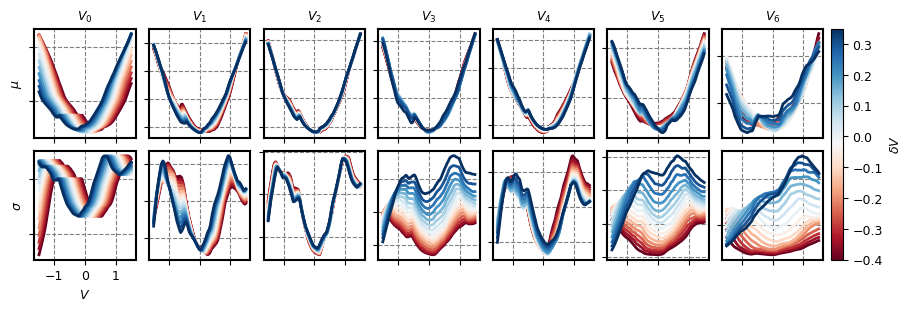

In [19]:
def z_scored(x):
    
    z = (x - x.mean()) / (x.std() + 1e-8) 
    
    return z

model.eval()

opt_params = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_parabola_vMB_0.npy', allow_pickle=True).item()
params = opt_params['params']

N = 100
v = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
funcs = []
"""for p_opt in params:
    c_v = torch.from_numpy(p_opt).float().expand(N, -1)
    #print(c_v)
    input_tensor = torch.cat([v, c_v], axis=1)
    out = model(input_tensor).detach().cpu().numpy()
    funcs.append(out[:, 0])
for i in range(len(funcs)):
    plt.plot(funcs[i])"""

opt_param = params[1]
perturbations = torch.arange(-0.4, 0.4, 0.05)
num_voltages = model.layer_dims[0]

fig, ax = plt.subplots(nrows=2, ncols=num_voltages, figsize=(9, 3), constrained_layout=True)

cmap = plt.get_cmap('RdBu')
#cmap = plt.get_cmap('cmr.redshift')
norm = plt.Normalize(vmin=perturbations[0], vmax=perturbations[-1])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), label=rf'$\delta V$', pad=0.01)

for i in range(num_voltages):
    for delta in perturbations:

        c_v = torch.from_numpy(opt_param).expand(N, -1).float()
        input_tensor = torch.cat([v, c_v], axis=1)
        input_tensor[:, i] += delta
        
        I = model(input_tensor)
        mu = I[..., 0].detach().numpy()
        std = np.exp(I[..., 1].detach().numpy())

        if i == 0:
            ax[0, i].set_ylabel(r'$\mu$')
            ax[1, i].set_ylabel(r'$\sigma$')

        act_func = nn.Sigmoid()
        ax[0, i].plot(v, z_scored(mu), color=cmap(norm(delta)), lw=2.0)
        ax[1, i].plot(v, std**2, color=cmap(norm(delta)), lw=2.0)
        #ax[0, i].plot(v, z_scored(act_func(v)))

        ax[0, i].tick_params(labelbottom=False)
        ax[0, i].set_title(rf'$V_{i}$')
        
        #ax[0, i].set_facecolor('lightgrey')
        #ax[1, i].set_facecolor('lightgrey')

        ax[0, i].spines[:].set_linewidth(1.5)
        ax[1, i].spines[:].set_linewidth(1.5)

        ax[0, i].tick_params(labelbottom=False)
        ax[1, i].tick_params(labelbottom=False)

        ax[0, i].tick_params(labelleft=False)
        ax[1, i].tick_params(labelleft=False)

        ax[0, i].grid(True, which='both', c='gray', ls='dashed')
        ax[1, i].grid(True, which='both', c='gray', ls='dashed')

        ax[1, 0].set_xlabel(r'$V$') 
        ax[1, 0].tick_params(labelbottom=True)
plt.savefig('test.pdf', bbox_inches='tight')
plt.show()